# Évaluation — Analyse approfondie des modèles

Ce notebook complète **`03_Modeling.ipynb`**. Il présente une évaluation approfondie des performances des modèles développés et une analyse détaillée du **modèle final retenu : Random Forest + RUS**.

L'objectif est d'évaluer la capacité du modèle à détecter les clients susceptibles de résilier, d'analyser ses erreurs de prédiction et d'expliquer ses décisions grâce à des techniques d'interprétabilité.

## Plan

1. Chargement des données et des modèles
2. Matrices de confusion — comparaison des modèles
3. Courbes ROC comparatives
4. Courbes Precision-Recall
5. Analyse des erreurs (Faux Positifs et Faux Négatifs)
6. Optimisation du seuil de décision
7. Importance des variables (Feature Importance)
8. Permutation Importance
9. Explicabilité avec SHAP (analyse globale et locale)
10. Synthèse des résultats et recommandations métier

## 1. Chargement des modèles et des données

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    average_precision_score
)
from sklearn.inspection import permutation_importance

print('✅ Librairies importées !')

✅ Librairies importées !


In [11]:
# Chargement des données de test
X_test = np.load('../models/X_test_prepared.npy')
y_test = np.load('../models/y_test.npy')

# Chargement des modèles entraînés
best_lr = joblib.load('../models/logistic_regression.pkl')
best_rf = joblib.load('../models/random_forest.pkl')
best_xgb = joblib.load('../models/xgboost.pkl')
best_mlp = joblib.load('../models/mlp.pkl')

# Chargement du modèle final retenu
best_model = joblib.load('../models/best_model.pkl')

# Liste des modèles à comparer
models = [
    (best_lr, 'Régression Logistique'),
    (best_rf, 'Random Forest + RUS'),
    (best_xgb, 'XGBoost + RUS'),
    (best_mlp, 'MLP + RUS'),
]

print("✅ Données et modèles chargés !")
print(f"   X_test : {X_test.shape} | y_test : {y_test.shape}")
print(f"   Churners dans le jeu de test : {y_test.sum()} / {len(y_test)} ({y_test.mean()*100:.1f}%)")
print("   Modèle final retenu : Random Forest + RUS")

✅ Données et modèles chargés !
   X_test : (2000, 51) | y_test : (2000,)
   Churners dans le jeu de test : 204 / 2000 (10.2%)
   Modèle final retenu : Random Forest + RUS


In [12]:
# Chargement du pipeline de prétraitement
preprocessor = joblib.load('../models/preprocessor.pkl')

# Variables numériques
num_features = list(preprocessor.transformers_[0][2])

# Variables catégorielles après One-Hot Encoding
cat_features = preprocessor.transformers_[1][1]['onehot'] \
    .get_feature_names_out(
        preprocessor.transformers_[1][2]
    ).tolist()

# Liste complète des variables après prétraitement
all_features = num_features + cat_features

print(f"✅ {len(all_features)} variables après prétraitement")
print(f"   • {len(num_features)} variables numériques")
print(f"   • {len(cat_features)} variables catégorielles (One-Hot Encoding)")

✅ 51 variables après prétraitement
   • 19 variables numériques
   • 32 variables catégorielles (One-Hot Encoding)


## 2. Matrices de confusion — Comparaison des modèles

La **matrice de confusion** permet d'analyser les performances d'un modèle de classification en comparant les prédictions aux valeurs réelles. Elle distingue quatre types de prédictions :

- **Vrais Positifs (VP)** : churners correctement détectés ;
- **Vrais Négatifs (VN)** : clients fidèles correctement identifiés ;
- **Faux Positifs (FP)** : clients fidèles prédits à tort comme churners ;
- **Faux Négatifs (FN)** : churners non détectés par le modèle.

Dans un contexte de **prédiction du churn**, les **faux négatifs (FN)** représentent l'erreur la plus coûteuse, car ils correspondent à des clients qui résilient sans avoir été identifiés. L'objectif est donc de limiter ces erreurs, ce qui explique l'importance accordée au **Recall** lors de la comparaison des modèles dans le notebook de modélisation.

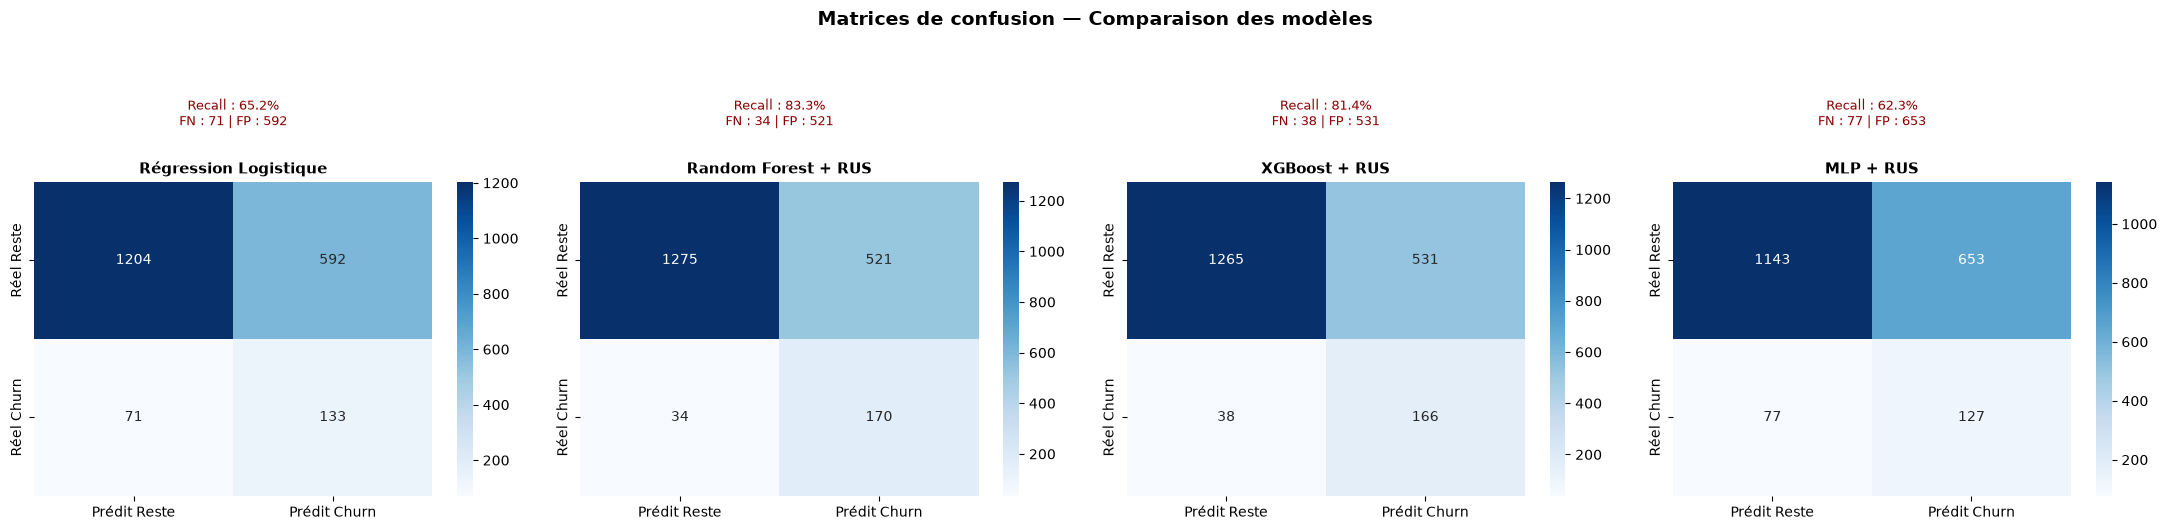

📊 Dans le contexte du churn, l'objectif principal est de réduire les faux négatifs (FN), car ils correspondent à des clients qui résilient sans avoir été détectés.


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (model, name) in zip(axes, models):

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Prédit Reste', 'Prédit Churn'],
        yticklabels=['Réel Reste', 'Réel Churn']
    )

    ax.set_title(name, fontsize=11, fontweight='bold')

    ax.text(
        0.5,
        1.18,
        f"Recall : {rec:.1%}\nFN : {cm[1,0]} | FP : {cm[0,1]}",
        ha='center',
        transform=ax.transAxes,
        fontsize=9,
        color='darkred'
    )

plt.suptitle(
    'Matrices de confusion — Comparaison des modèles',
    fontsize=14,
    fontweight='bold',
    y=1.05
)

plt.tight_layout()
plt.show()

print("📊 Dans le contexte du churn, l'objectif principal est de réduire les faux négatifs (FN), car ils correspondent à des clients qui résilient sans avoir été détectés.")

In [14]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred_final,
    target_names=["Reste (0)", "Churn (1)"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df.round(3))

,precision,recall,f1-score,support
Reste (0),0.974,0.710,0.821,1796.000
Churn (1),0.246,0.833,0.380,204.000
accuracy,0.722,0.722,0.722,0.722
macro avg,0.610,0.772,0.601,2000.000
weighted avg,0.900,0.722,0.776,2000.000


## 3. Courbes ROC comparatives

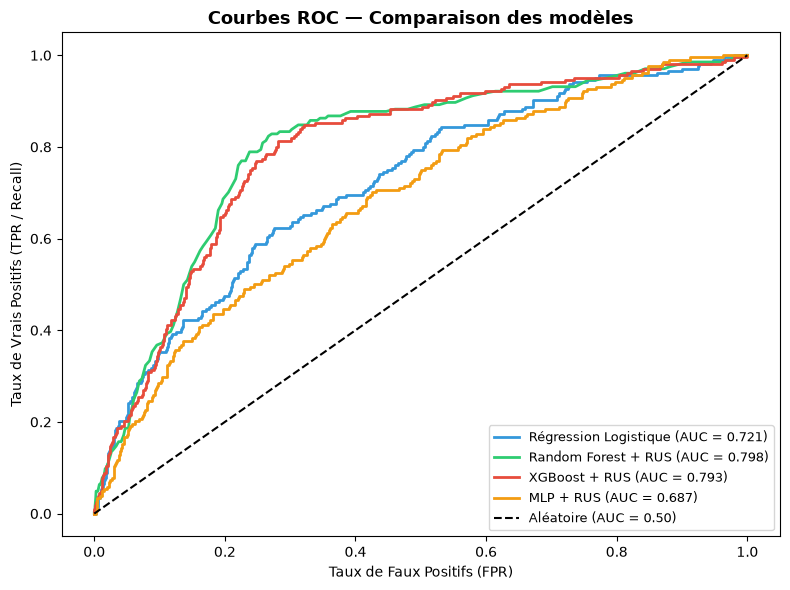

📊 Plus une courbe ROC est proche du coin supérieur gauche, meilleure est la capacité du modèle à distinguer les churners des clients fidèles.


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (model, name), color in zip(models, colors):

    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)

    auc = roc_auc_score(y_test, y_proba)

    ax.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f'{name} (AUC = {auc:.3f})'
    )

ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Aléatoire (AUC = 0.50)'
)

ax.set_title(
    'Courbes ROC — Comparaison des modèles',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR / Recall)')

ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print(
    "📊 Plus une courbe ROC est proche du coin supérieur gauche, "
    "meilleure est la capacité du modèle à distinguer les churners des clients fidèles."
)

## 4. Courbe Precision-Recall (PR-AUC)

La courbe PR est plus informative que la ROC sur des données **déséquilibrées** (90/10). Elle mesure la capacité du modèle à détecter les churners (Recall) sans générer trop de fausses alarmes (Precision).

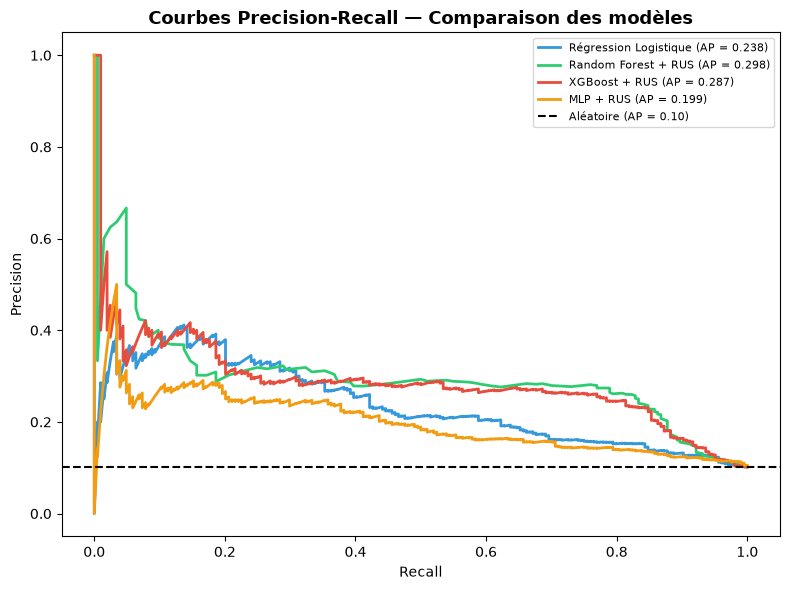

📊 Plus la courbe Precision-Recall est proche du coin supérieur droit, meilleur est le compromis entre Precision et Recall pour détecter les churners.


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (model, name), color in zip(models, colors):

    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    ap = average_precision_score(y_test, y_proba)

    ax.plot(
        recall,
        precision,
        color=color,
        linewidth=2,
        label=f"{name} (AP = {ap:.3f})"
    )

# Performance d'un classifieur aléatoire
baseline = y_test.mean()

ax.axhline(
    y=baseline,
    color='black',
    linestyle='--',
    label=f"Aléatoire (AP = {baseline:.2f})"
)

ax.set_title(
    "Courbes Precision-Recall — Comparaison des modèles",
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print(
    "📊 Plus la courbe Precision-Recall est proche du coin supérieur droit, "
    "meilleur est le compromis entre Precision et Recall pour détecter les churners."
)

## 5. Analyse des erreurs

L'analyse des erreurs va au-delà des scores globaux : elle identifie **quels clients** sont mal prédits et **pourquoi**, pour formuler des recommandations réalistes.

📊 Analyse des erreurs — Random Forest + RUS (modèle final)
   ✅ Vrais Positifs (TP) :  170 — Churners correctement détectés
   ✅ Vrais Négatifs (TN) : 1275 — Clients fidèles correctement identifiés
   ⚠️ Faux Positifs (FP) :  521 — Clients fidèles classés à tort comme churners
   ❌ Faux Négatifs (FN) :   34 — Churners non détectés

💡 Analyse métier :
   • Un faux négatif (FN) correspond à un client qui résilie sans avoir été identifié.
     Il représente la perte métier la plus importante.
   • Un faux positif (FP) déclenche une action de rétention inutile,
     ce qui engendre un coût marketing mais reste moins critique.
   • Notre objectif est donc de limiter les faux négatifs, ce qui justifie
     l'importance accordée au Recall dans ce projet.


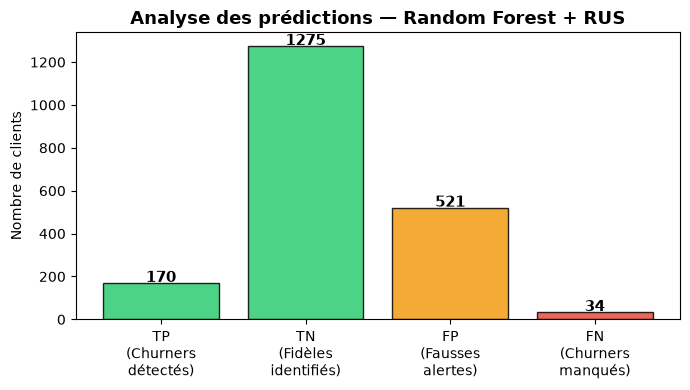

In [17]:
# Prédictions du modèle final
y_pred_final = best_model.predict(X_test)
y_proba_final = best_model.predict_proba(X_test)[:, 1]

# Calcul des composantes de la matrice de confusion
tp = int(((y_pred_final == 1) & (y_test == 1)).sum())
tn = int(((y_pred_final == 0) & (y_test == 0)).sum())
fp = int(((y_pred_final == 1) & (y_test == 0)).sum())
fn = int(((y_pred_final == 0) & (y_test == 1)).sum())

print("📊 Analyse des erreurs — Random Forest + RUS (modèle final)")
print("=" * 70)
print(f"   ✅ Vrais Positifs (TP) : {tp:4d} — Churners correctement détectés")
print(f"   ✅ Vrais Négatifs (TN) : {tn:4d} — Clients fidèles correctement identifiés")
print(f"   ⚠️ Faux Positifs (FP) : {fp:4d} — Clients fidèles classés à tort comme churners")
print(f"   ❌ Faux Négatifs (FN) : {fn:4d} — Churners non détectés")

print("\n💡 Analyse métier :")
print("   • Un faux négatif (FN) correspond à un client qui résilie sans avoir été identifié.")
print("     Il représente la perte métier la plus importante.")
print("   • Un faux positif (FP) déclenche une action de rétention inutile,")
print("     ce qui engendre un coût marketing mais reste moins critique.")
print("   • Notre objectif est donc de limiter les faux négatifs, ce qui justifie")
print("     l'importance accordée au Recall dans ce projet.")

# Visualisation
fig, ax = plt.subplots(figsize=(7, 4))

categories = [
    "TP\n(Churners\ndétectés)",
    "TN\n(Fidèles\nidentifiés)",
    "FP\n(Fausses\nalertes)",
    "FN\n(Churners\nmanqués)"
]

values = [tp, tn, fp, fn]

bar_colors = ['#2ecc71', '#2ecc71', '#f39c12', '#e74c3c']

bars = ax.bar(
    categories,
    values,
    color=bar_colors,
    edgecolor='black',
    alpha=0.85
)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(val),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    "Analyse des prédictions — Random Forest + RUS",
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

In [18]:
print(f"\n📌 Synthèse :")
print(f"Le modèle détecte {tp} churners mais en manque {fn}.")
print("La priorité est de réduire les faux négatifs afin de maximiser les actions de rétention.")


📌 Synthèse :
Le modèle détecte 170 churners mais en manque 34.
La priorité est de réduire les faux négatifs afin de maximiser les actions de rétention.


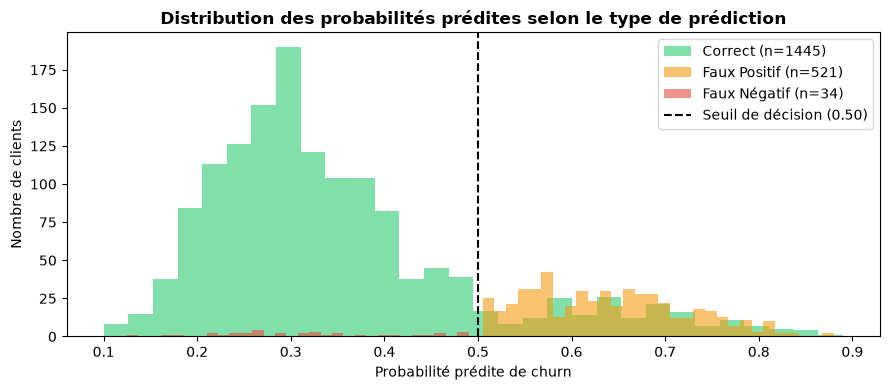

📊 Les faux négatifs présentent généralement une probabilité de churn proche du seuil de décision.
📊 Une diminution du seuil permettrait d'augmenter le Recall en détectant davantage de churners,
   mais entraînerait également une augmentation du nombre de faux positifs.


In [19]:
# Distribution des probabilités prédites selon le type de prédiction

df_errors = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_final,
    "proba": y_proba_final
})

df_errors["type"] = "Correct"

df_errors.loc[
    (df_errors["y_pred"] == 1) & (df_errors["y_true"] == 0),
    "type"
] = "Faux Positif"

df_errors.loc[
    (df_errors["y_pred"] == 0) & (df_errors["y_true"] == 1),
    "type"
] = "Faux Négatif"

fig, ax = plt.subplots(figsize=(9, 4))

for etype, color in [
    ("Correct", "#2ecc71"),
    ("Faux Positif", "#f39c12"),
    ("Faux Négatif", "#e74c3c")
]:
    subset = df_errors[df_errors["type"] == etype]

    ax.hist(
        subset["proba"],
        bins=30,
        alpha=0.6,
        label=f"{etype} (n={len(subset)})",
        color=color
    )

ax.axvline(
    x=0.5,
    color="black",
    linestyle="--",
    label="Seuil de décision (0.50)"
)

ax.set_title(
    "Distribution des probabilités prédites selon le type de prédiction",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Probabilité prédite de churn")
ax.set_ylabel("Nombre de clients")

ax.legend()

plt.tight_layout()
plt.show()

print("📊 Les faux négatifs présentent généralement une probabilité de churn proche du seuil de décision.")
print("📊 Une diminution du seuil permettrait d'augmenter le Recall en détectant davantage de churners,")
print("   mais entraînerait également une augmentation du nombre de faux positifs.")

## 6. Optimisation du seuil de décision

Par défaut, un modèle de classification utilise un **seuil de décision de 0,5** : lorsqu'un client présente une probabilité de churn supérieure ou égale à 0,5, il est classé comme **churner**.

Cependant, ce seuil n'est pas toujours optimal. Dans un contexte de **prédiction du churn**, l'objectif est de détecter le plus grand nombre possible de clients à risque. Il peut donc être pertinent **d'abaisser le seuil de décision** afin d'augmenter le **Recall**, quitte à générer davantage de faux positifs et donc davantage d'actions de rétention.

Cette analyse permet d'identifier un compromis entre les performances du modèle et les contraintes métier.

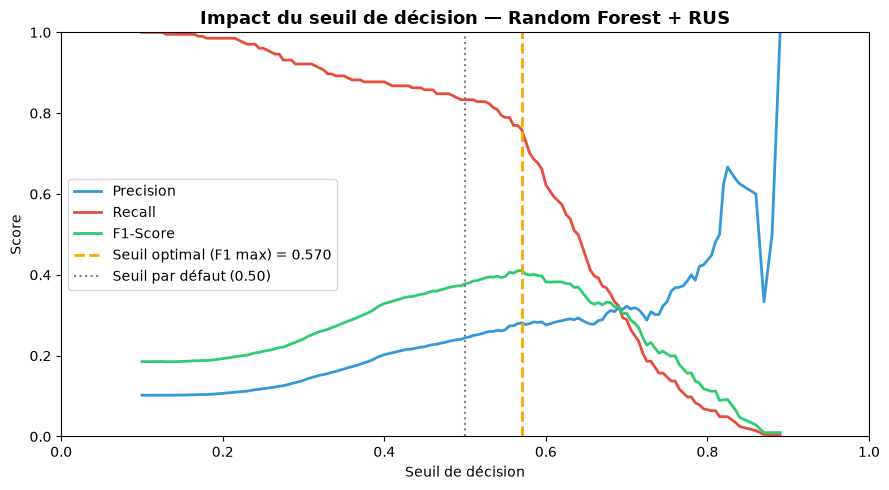


📊 Seuil optimal (F1 maximal) : 0.570
   Recall    : 0.7598 (vs 0.8333 au seuil 0.50)
   Precision : 0.2813 (vs 0.2460 au seuil 0.50)
   F1-Score  : 0.4106 (vs 0.3799 au seuil 0.50)

💡 Analyse métier :
Un seuil plus faible permet de détecter davantage de churners (Recall plus élevé),
mais augmente également le nombre de faux positifs et donc le coût des campagnes de rétention.
Le choix du seuil dépend du compromis souhaité entre coût métier et capacité de détection.


In [20]:
precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_proba_final
)

f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)

best_idx = np.argmax(f1_scores)
best_thr = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    thresholds,
    precisions[:-1],
    label='Precision',
    color='#3498db',
    linewidth=2
)

ax.plot(
    thresholds,
    recalls[:-1],
    label='Recall',
    color='#e74c3c',
    linewidth=2
)

ax.plot(
    thresholds,
    f1_scores[:-1],
    label='F1-Score',
    color='#2ecc71',
    linewidth=2
)

ax.axvline(
    x=best_thr,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'Seuil optimal (F1 max) = {best_thr:.3f}'
)

ax.axvline(
    x=0.5,
    color='gray',
    linestyle=':',
    linewidth=1.5,
    label='Seuil par défaut (0.50)'
)

ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Score")

ax.set_title(
    "Impact du seuil de décision — Random Forest + RUS",
    fontsize=13,
    fontweight="bold"
)

ax.legend()

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Évaluation au seuil optimal
y_pred_opt = (y_proba_final >= best_thr).astype(int)

print(f"\n📊 Seuil optimal (F1 maximal) : {best_thr:.3f}")
print(f"   Recall    : {recall_score(y_test, y_pred_opt):.4f} (vs {recall_score(y_test, y_pred_final):.4f} au seuil 0.50)")
print(f"   Precision : {precision_score(y_test, y_pred_opt):.4f} (vs {precision_score(y_test, y_pred_final):.4f} au seuil 0.50)")
print(f"   F1-Score  : {f1_score(y_test, y_pred_opt):.4f} (vs {f1_score(y_test, y_pred_final):.4f} au seuil 0.50)")

print("\n💡 Analyse métier :")
print("Un seuil plus faible permet de détecter davantage de churners (Recall plus élevé),")
print("mais augmente également le nombre de faux positifs et donc le coût des campagnes de rétention.")
print("Le choix du seuil dépend du compromis souhaité entre coût métier et capacité de détection.")

## 7. Feature Importance native — XGBoost

La Feature Importance mesure la contribution globale de chaque variable dans les décisions du modèle. XGBoost calcule l'importance par **gain** : l'amélioration moyenne de la fonction de perte apportée par chaque feature lors des splits.

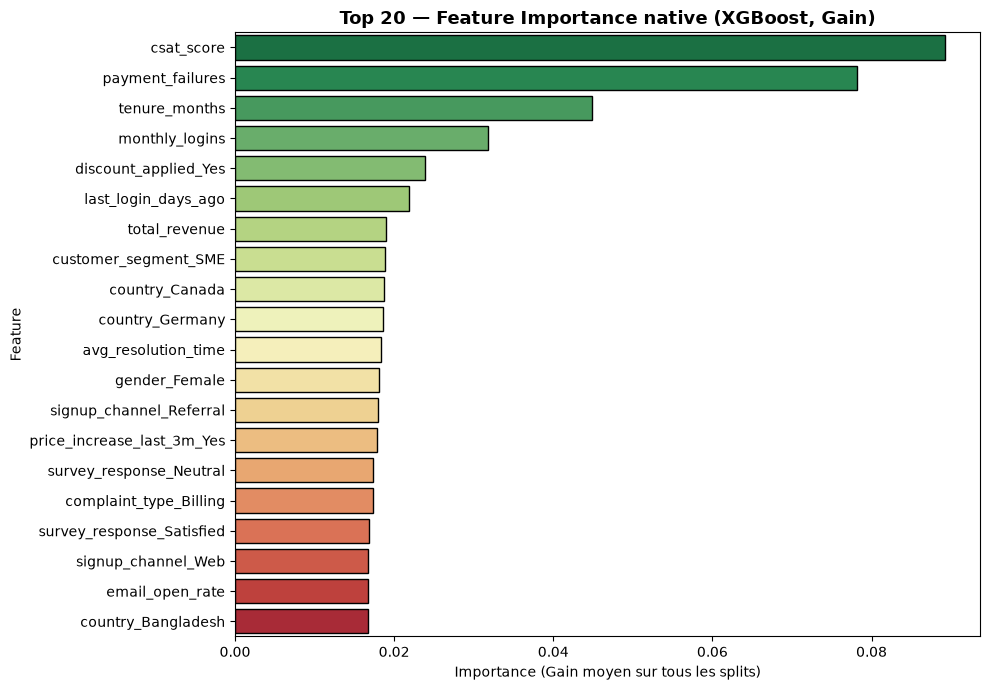


📊 Top 10 variables les plus influentes :


,Feature,Importance
0,csat_score,0.089173
1,payment_failures,0.078228
2,tenure_months,0.044901
3,monthly_logins,0.031825
4,discount_applied_Yes,0.023823
5,last_login_days_ago,0.021883
6,total_revenue,0.018956
7,customer_segment_SME,0.018849
8,country_Canada,0.018734
9,country_Germany,0.018577


In [15]:
importances = xgb.feature_importances_
feat_df     = pd.DataFrame({'Feature': all_features, 'Importance': importances})\
                .sort_values('Importance', ascending=False)

top20 = feat_df.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=top20, x='Importance', y='Feature',
            palette='RdYlGn_r', edgecolor='black')
plt.title('Top 20 — Feature Importance native (XGBoost, Gain)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance (Gain moyen sur tous les splits)')
plt.tight_layout()
plt.show()

print('\n📊 Top 10 variables les plus influentes :')
display(top20.head(10).reset_index(drop=True))

## 8. Permutation Importance — Méthode agnostique

La Permutation Importance est plus fiable que l'importance native : elle mesure la **perte réelle de performance** quand une variable est mélangée aléatoirement. Elle fonctionne avec tous les modèles et évite le biais des variables à forte cardinalité.

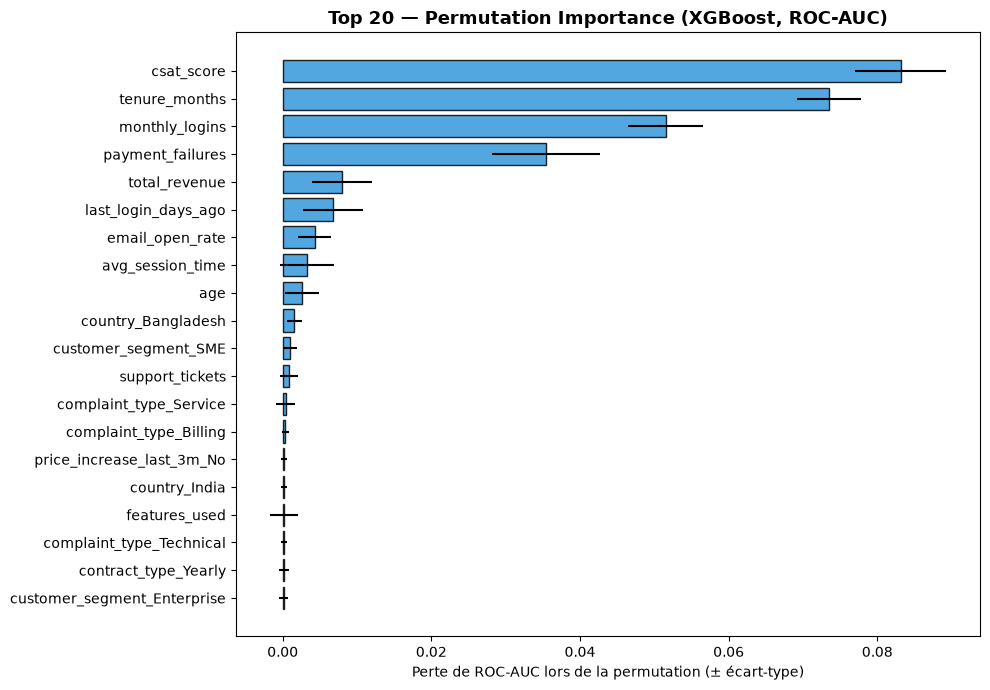

📊 Plus la barre est longue, plus la variable est essentielle.
   L'écart-type (barres d'erreur) mesure la stabilité de cette importance.


In [16]:
perm = permutation_importance(
    xgb, X_test, y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'         : all_features,
    'Importance_mean' : perm.importances_mean,
    'Importance_std'  : perm.importances_std
}).sort_values('Importance_mean', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(perm_df['Feature'][::-1],
         perm_df['Importance_mean'][::-1],
         xerr=perm_df['Importance_std'][::-1],
         color='#3498db', alpha=0.85, edgecolor='black')
plt.title('Top 20 — Permutation Importance (XGBoost, ROC-AUC)',
          fontsize=13, fontweight='bold')
plt.xlabel('Perte de ROC-AUC lors de la permutation (± écart-type)')
plt.tight_layout()
plt.show()

print('📊 Plus la barre est longue, plus la variable est essentielle.')
print('   L\'écart-type (barres d\'erreur) mesure la stabilité de cette importance.')

## 9. SHAP — Explicabilité locale et globale

SHAP (SHapley Additive exPlanations) répond à : *"Pourquoi ce client précis a-t-il une probabilité de churn de X% ?"*

Contrairement à la Feature Importance globale, SHAP explique chaque prédiction individuellement et indique si chaque variable **augmente** ou **réduit** le risque de churn.

In [17]:
try:
    import shap
    shap_ok = True
    print('✅ SHAP disponible !')
except ImportError:
    shap_ok = False
    print('⚠️  SHAP non installé. Lancer : pip install shap')

if shap_ok:
    explainer   = shap.TreeExplainer(xgb)
    sample_size = min(500, X_test.shape[0])
    X_sample    = X_test[:sample_size]
    shap_values = explainer.shap_values(X_sample)
    print(f'✅ Valeurs SHAP calculées sur {sample_size} clients du jeu de test.')

✅ SHAP disponible !
✅ Valeurs SHAP calculées sur 500 clients du jeu de test.


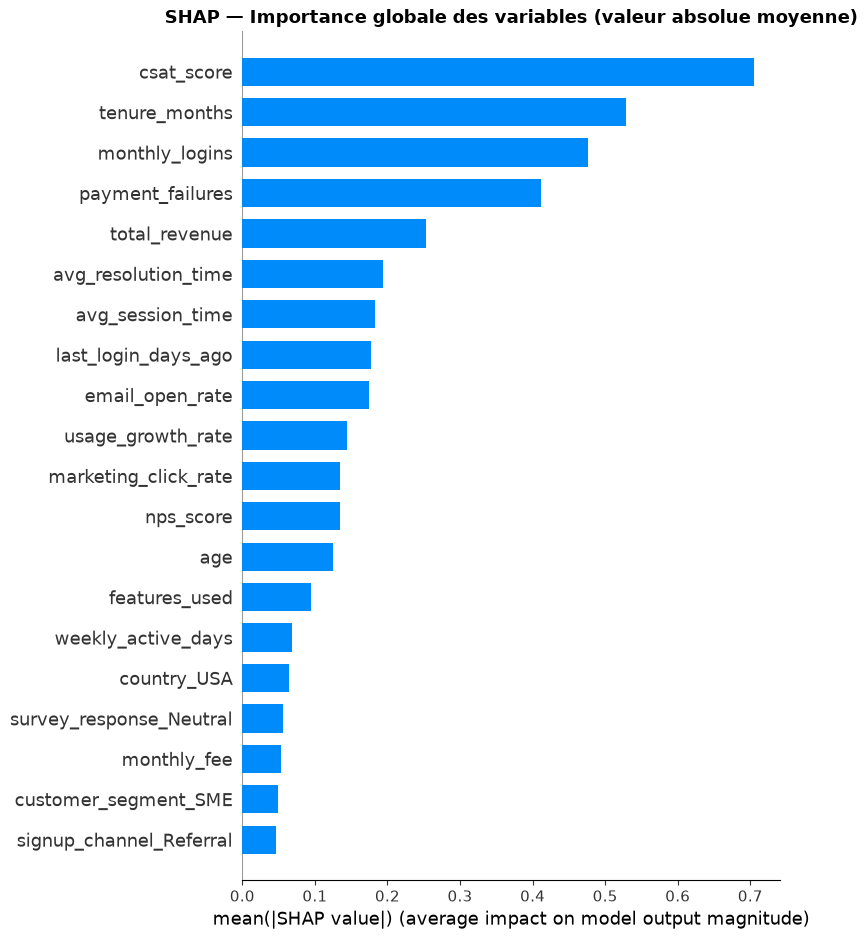

In [18]:
if shap_ok:
    # 9.1 Summary plot — importance globale (barres)
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values, X_sample,
        feature_names=all_features,
        plot_type='bar',
        show=False
    )
    plt.title('SHAP — Importance globale des variables (valeur absolue moyenne)',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

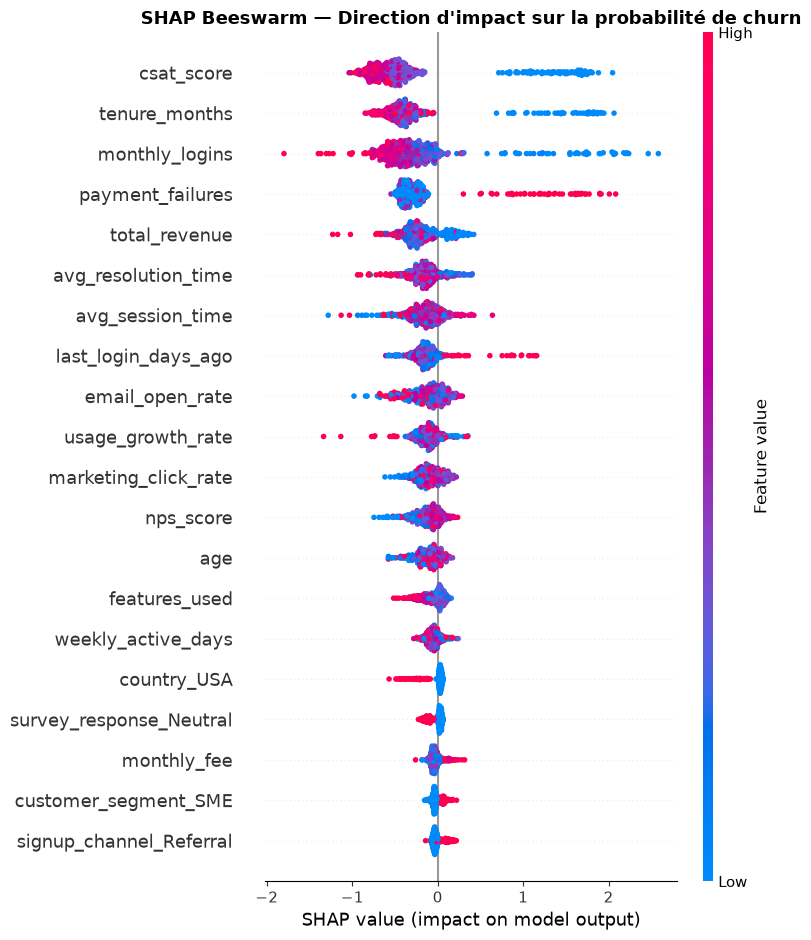

📊 Rouge = valeur élevée de la feature | Bleu = valeur faible
   Point à droite (SHAP > 0) → augmente la probabilité de churn
   Point à gauche (SHAP < 0) → réduit la probabilité de churn


In [19]:
if shap_ok:
    # 9.2 Beeswarm — direction d'impact (positif/négatif)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values, X_sample,
        feature_names=all_features,
        show=False
    )
    plt.title('SHAP Beeswarm — Direction d\'impact sur la probabilité de churn',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('📊 Rouge = valeur élevée de la feature | Bleu = valeur faible')
    print('   Point à droite (SHAP > 0) → augmente la probabilité de churn')
    print('   Point à gauche (SHAP < 0) → réduit la probabilité de churn')

🔍 Client le plus à risque dans l'échantillon :
   Index        : 365
   P(churn)     : 0.8820
   Churn réel   : 1


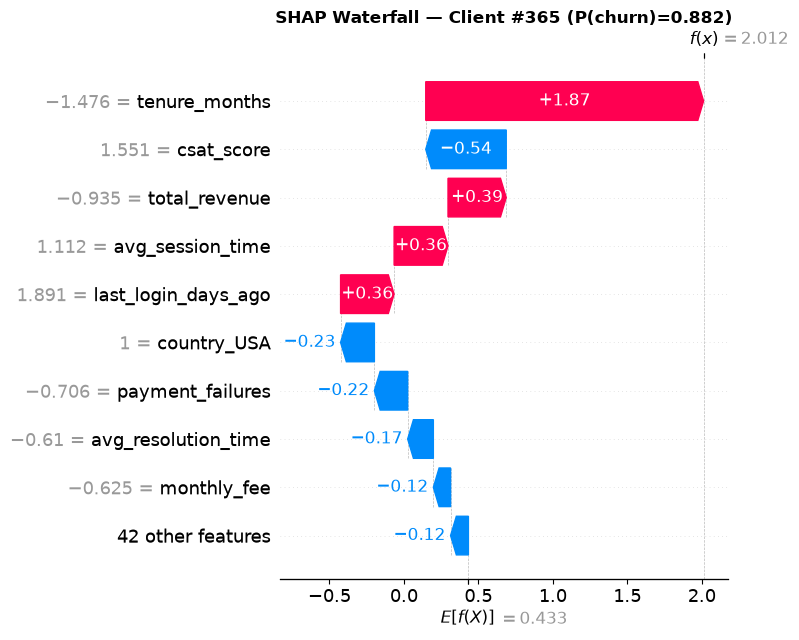


📊 Lecture : chaque barre montre la contribution (+ ou -) d'une variable
   à partir de la probabilité moyenne de churn du dataset (base_value).


In [20]:
if shap_ok:
    # 9.3 Waterfall — explication locale pour un client à haut risque
    y_proba_sample = xgb.predict_proba(X_sample)[:, 1]
    high_risk_idx  = int(np.argmax(y_proba_sample))

    print(f'🔍 Client le plus à risque dans l\'échantillon :')
    print(f'   Index        : {high_risk_idx}')
    print(f'   P(churn)     : {y_proba_sample[high_risk_idx]:.4f}')
    print(f'   Churn réel   : {int(y_test[high_risk_idx])}')

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[high_risk_idx],
            base_values=explainer.expected_value,
            data=X_sample[high_risk_idx],
            feature_names=all_features
        ),
        show=False
    )
    plt.title(f'SHAP Waterfall — Client #{high_risk_idx} (P(churn)={y_proba_sample[high_risk_idx]:.3f})',
              fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('\n📊 Lecture : chaque barre montre la contribution (+ ou -) d\'une variable')
    print('   à partir de la probabilité moyenne de churn du dataset (base_value).')

🔍 Exemple de Faux Négatif (churner manqué) :
   Index        : 17
   P(churn)     : 0.2617  (< seuil 0.5 → prédit fidèle)
   Churn réel   : 1 (ce client a churné !)


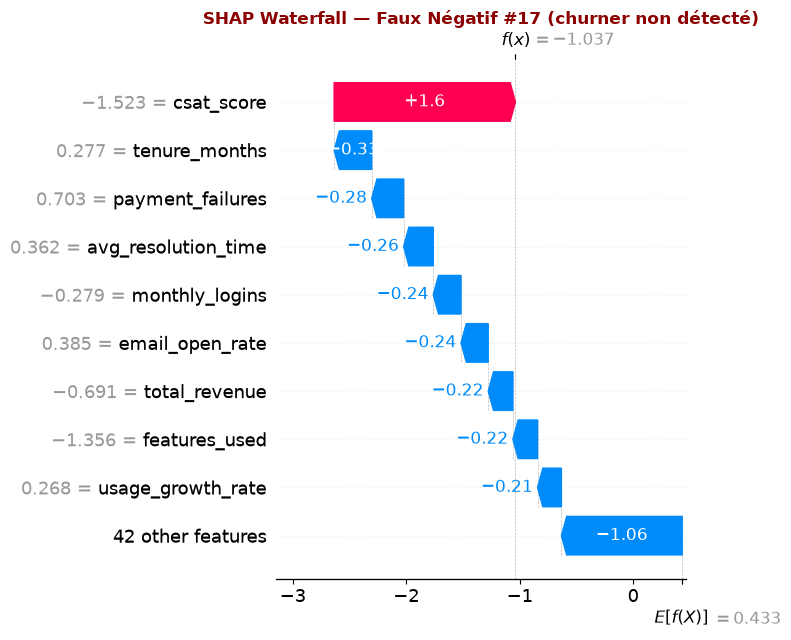

In [21]:
if shap_ok:
    # 9.4 Waterfall — explication locale pour un Faux Négatif
    # Un FN = churner réel prédit comme fidèle → cas le plus problématique
    y_pred_sample = xgb.predict(X_sample)
    fn_mask       = (y_pred_sample == 0) & (y_test[:sample_size] == 1)

    if fn_mask.sum() > 0:
        fn_idx = int(np.where(fn_mask)[0][0])
        print(f'🔍 Exemple de Faux Négatif (churner manqué) :')
        print(f'   Index        : {fn_idx}')
        print(f'   P(churn)     : {y_proba_sample[fn_idx]:.4f}  (< seuil 0.5 → prédit fidèle)')
        print(f'   Churn réel   : 1 (ce client a churné !)')

        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values[fn_idx],
                base_values=explainer.expected_value,
                data=X_sample[fn_idx],
                feature_names=all_features
            ),
            show=False
        )
        plt.title(f'SHAP Waterfall — Faux Négatif #{fn_idx} (churner non détecté)',
                  fontweight='bold', color='darkred')
        plt.tight_layout()
        plt.show()
    else:
        print('ℹ️  Aucun FN dans cet échantillon de 500 clients.')

## 10. Synthèse et recommandations métier

### 10.1 Tableau récapitulatif final

In [9]:
def get_metrics(model, name):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Modèle'    : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_proba), 4),
        'PR-AUC'    : round(average_precision_score(y_test, y_proba), 4)
    }

final_results = pd.DataFrame([
    get_metrics(lr,      'Régression Logistique'),
    get_metrics(best_rf, 'Random Forest + SMOTE'),
    get_metrics(xgb,     'XGBoost ✅'),
    get_metrics(mlp,     'MLP (Deep Learning)')
]).set_index('Modèle')

print('📊 Tableau récapitulatif final — Toutes métriques')
display(
    final_results.style
    .highlight_max(axis=0, color='#d4f0d4')
    .highlight_min(axis=0, color='#f0d4d4')
    .format('{:.4f}')
)

📊 Tableau récapitulatif final — Toutes métriques


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Modèle,,,,,,
Régression Logistique,0.6685,0.1834,0.6520,0.2863,0.7212,0.2381
Random Forest + SMOTE,0.8965,0.3636,0.0196,0.0372,0.7877,0.2667
XGBoost ✅,0.8410,0.2564,0.2941,0.2740,0.7718,0.2469
MLP (Deep Learning),0.8495,0.2350,0.2108,0.2222,0.6669,0.1950


### 10.2 Interprétation des résultats SHAP — Logique métier

Les analyses SHAP permettent d'identifier les **leviers actionnables** pour les équipes CRM/marketing :

**Variables augmentant le risque de churn :**
- `payment_failures` élevé → signal critique de friction financière
- `support_tickets` élevé → insatisfaction produit ou service
- `nps_score` faible → client déjà détracteur, probabilité de départ forte
- `last_login_days_ago` élevé → désengagement comportemental

**Variables réduisant le risque de churn :**
- `tenure_months` élevé → fidélité installée, inertie positive
- `monthly_logins` élevé → engagement actif
- `total_revenue` élevé → client à forte valeur, plus investi dans le service

**Distinction causalité / corrélation :**
Un NPS faible est *corrélé* au churn mais n'en est pas nécessairement la cause directe. Il peut refléter une mauvaise expérience produit ou un manque d'accompagnement. Agir sur le NPS (ex. enquête, contact personnalisé) peut casser la chaîne menant au churn.

### 10.3 Recommandations opérationnelles

1. **Priorisation des contacts** : cibler en priorité les clients avec P(churn) > seuil optimal, en commençant par ceux à forte valeur revenue (`total_revenue` élevé).
2. **Alertes automatiques** : déclencher une alerte CRM dès 2+ échecs de paiement (`payment_failures`).
3. **Programme de réengagement** : contacter les clients inactifs depuis > 30 jours (`last_login_days_ago`).
4. **Suivi NPS proactif** : relancer les clients avec NPS < 6 avec un accompagnement personnalisé.
5. **Seuil de décision adaptatif** : si le budget rétention est limité, hausser le seuil pour cibler uniquement les churners les plus certains ; si le budget est large, l'abaisser pour maximiser le Recall.

### 10.4 Limites du modèle

- **Données synthétiques** : le dataset est généré artificiellement. Les performances réelles sur données terrain peuvent différer.
- **Dérive temporelle** : le comportement client évolue. Le modèle doit être ré-entraîné périodiquement.
- **Variables manquantes** : des signaux externes (promotions concurrentes, incidents service) ne sont pas capturés.
- **Instabilité SHAP** : les valeurs SHAP peuvent légèrement varier selon le split train/test et la taille de l'échantillon.

In [22]:
print('='*60)
print('  ✅ ÉVALUATION COMPLÈTE — RÉSUMÉ FINAL')
print('='*60)
print('  Modèle final retenu    : XGBoost')
print(f'  Recall (test)          : {recall_score(y_test, y_pred_xgb):.4f}')
print(f'  F1-Score (test)        : {f1_score(y_test, y_pred_xgb):.4f}')
print(f'  ROC-AUC (test)         : {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'  Seuil optimal (F1)     : {best_thr:.2f}')
print('  Interprétabilité       : SHAP (TreeExplainer)')
print('  Prochaine étape        : dashboard/app.py (Streamlit)')
print('='*60)

  ✅ ÉVALUATION COMPLÈTE — RÉSUMÉ FINAL
  Modèle final retenu    : XGBoost
  Recall (test)          : 0.2941
  F1-Score (test)        : 0.2740
  ROC-AUC (test)         : 0.7718
  Seuil optimal (F1)     : 0.23
  Interprétabilité       : SHAP (TreeExplainer)
  Prochaine étape        : dashboard/app.py (Streamlit)


# Conclusion

L'évaluation des différents modèles a permis d'identifier XGBoost comme le modèle le plus performant pour la prédiction du churn.

Les analyses réalisées (métriques, courbes ROC et Precision-Recall, matrices de confusion, importance des variables et SHAP) montrent que ce modèle offre le meilleur compromis entre performance prédictive et interprétabilité.

Ces résultats serviront de base au développement du dashboard interactif destiné à faciliter la prise de décision métier.